In [2]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tifffile

from tqdm import tqdm

from sklearn.manifold import TSNE

In [3]:
MS_DIR = "../EuroSAT_Dataset/EuroSATallBands"

TRAIN_CSV = "../EuroSAT_Dataset/train.csv"

FIGURE_DIR = "../outputs/figures"

os.makedirs(FIGURE_DIR, exist_ok=True)

print("MS Directory :", MS_DIR)
print("Train CSV    :", TRAIN_CSV)
print("Figure Dir   :", FIGURE_DIR)

MS Directory : ../EuroSAT_Dataset/EuroSATallBands
Train CSV    : ../EuroSAT_Dataset/train.csv
Figure Dir   : ../outputs/figures


In [4]:
train_df = pd.read_csv(TRAIN_CSV)

print("Total Images :", len(train_df))
print("Total Classes:", train_df["classname"].nunique())

display(train_df.head())

Total Images : 18900
Total Classes: 10


,filename,label,classname
0,AnnualCrop\AnnualCrop_683.jpg,0,AnnualCrop
1,AnnualCrop\AnnualCrop_2035.jpg,0,AnnualCrop
2,AnnualCrop\AnnualCrop_842.jpg,0,AnnualCrop
3,AnnualCrop\AnnualCrop_1092.jpg,0,AnnualCrop
4,AnnualCrop\AnnualCrop_1327.jpg,0,AnnualCrop


In [5]:
def compute_ndvi(img):
    red = img[3].astype(np.float32)      # Band 4 (Red)
    nir = img[7].astype(np.float32)      # Band 8 (NIR)

    return (nir - red) / (nir + red + 1e-8)


def compute_ndwi(img):
    green = img[2].astype(np.float32)    # Band 3 (Green)
    nir = img[7].astype(np.float32)      # Band 8 (NIR)

    return (green - nir) / (green + nir + 1e-8)


def compute_ndbi(img):
    swir = img[10].astype(np.float32)    # Band 11 (SWIR)
    nir = img[7].astype(np.float32)      # Band 8 (NIR)

    return (swir - nir) / (swir + nir + 1e-8)

In [10]:
sample_path = os.path.join(
    MS_DIR,
    "train",
    train_df.iloc[0]["filename"].replace(".jpg", ".tif")
)

print(sample_path)

img = tifffile.imread(sample_path)

print("Image Shape:", img.shape)
print("Data Type:", img.dtype)
if img.shape[-1] == 13:
    img = np.transpose(img, (2, 0, 1))

print("Processed Shape:", img.shape)

../EuroSAT_Dataset/EuroSATallBands\train\AnnualCrop\AnnualCrop_683.tif
Image Shape: (64, 64, 13)
Data Type: uint16
Processed Shape: (13, 64, 64)


In [11]:
ndvi = compute_ndvi(img)
ndwi = compute_ndwi(img)
ndbi = compute_ndbi(img)

band_means = img.mean(axis=(1, 2))

print(f"Mean NDVI : {ndvi.mean():.4f}")
print(f"Mean NDWI : {ndwi.mean():.4f}")
print(f"Mean NDBI : {ndbi.mean():.4f}")

print("\nBand Means")

for i, value in enumerate(band_means):
    print(f"B{i+1:02d}: {value:.2f}")

Mean NDVI : 0.6223
Mean NDWI : -0.5090
Mean NDBI : -0.2670

Band Means
B01: 1253.15
B02: 1002.69
B03: 961.90
B04: 686.07
B05: 1004.69
B06: 2488.59
B07: 3202.73
B08: 2976.85
B09: 564.74
B10: 10.25
B11: 1712.65
B12: 800.82
B13: 3471.86


In [12]:
def extract_features(img):

    if img.shape[-1] == 13:
        img = np.transpose(img, (2, 0, 1))

    ndvi = compute_ndvi(img).mean()
    ndwi = compute_ndwi(img).mean()
    ndbi = compute_ndbi(img).mean()

    band_means = img.mean(axis=(1, 2))

    features = {
        "NDVI": ndvi,
        "NDWI": ndwi,
        "NDBI": ndbi
    }

    for i in range(13):
        features[f"B{i+1}"] = band_means[i]

    return features

In [13]:
records = []

for _, row in tqdm(train_df.iterrows(), total=len(train_df)):

    img_path = os.path.join(
        MS_DIR,
        "train",
        row["filename"].replace(".jpg", ".tif")
    )

    img = tifffile.imread(img_path)

    features = extract_features(img)

    features["classname"] = row["classname"]
    features["label"] = row["label"]

    records.append(features)

feature_df = pd.DataFrame(records)

print("Feature DataFrame Shape:", feature_df.shape)

feature_df.head()

100%|██████████| 18900/18900 [02:58<00:00, 106.18it/s]


Feature DataFrame Shape: (18900, 18)


,NDVI,NDWI,NDBI,B1,B2,B3,B4,B5,B6,B7,B8,B9,B10,B11,B12,B13,classname,label
0,0.622316,-0.508975,-0.266997,1253.154785,1002.690674,961.897949,686.074707,1004.693604,2488.586426,3202.731445,2976.853760,564.735107,10.249512,1712.645264,800.822266,3471.855469,AnnualCrop,0
1,0.229259,-0.293470,0.092570,1672.066406,1601.828369,1664.692871,1932.335205,2152.745361,2832.455322,3228.053223,3088.992676,726.006104,15.598145,3724.273682,2833.703369,3550.711182,AnnualCrop,0
2,0.190711,-0.272308,0.101259,1429.684814,1275.101318,1312.430908,1569.234375,1743.582031,2116.386963,2365.624756,2332.753418,782.765869,12.377930,2853.605225,2085.723145,2594.812012,AnnualCrop,0
3,0.382773,-0.460044,-0.158925,1366.667725,1242.337402,1314.340820,1581.845947,1982.329102,3097.277100,3730.083008,3680.226074,1072.926025,12.764160,2606.924805,1440.965820,4306.681641,AnnualCrop,0
4,0.162643,-0.245796,0.113843,1432.065186,1288.161133,1341.239502,1605.499756,1764.315918,2060.484131,2285.408936,2219.954834,724.769043,13.104004,2785.394775,2167.130615,2472.804932,AnnualCrop,0


In [14]:
feature_df.to_csv(
    "../outputs/environment_features.csv",
    index=False
)

print("Feature table saved successfully!")

Feature table saved successfully!


In [16]:
# Load extracted features 
feature_df = pd.read_csv("../outputs/environment_features.csv")

print("Feature Data Loaded Successfully!")
print(feature_df.shape)

feature_df.head()

Feature Data Loaded Successfully!
(18900, 18)


,NDVI,NDWI,NDBI,B1,B2,B3,B4,B5,B6,B7,B8,B9,B10,B11,B12,B13,classname,label
0,0.622316,-0.508975,-0.266997,1253.154785,1002.690674,961.897949,686.074707,1004.693604,2488.586426,3202.731445,2976.853760,564.735107,10.249512,1712.645264,800.822266,3471.855469,AnnualCrop,0
1,0.229259,-0.293470,0.092570,1672.066406,1601.828369,1664.692871,1932.335205,2152.745361,2832.455322,3228.053223,3088.992676,726.006104,15.598145,3724.273682,2833.703369,3550.711182,AnnualCrop,0
2,0.190711,-0.272308,0.101259,1429.684814,1275.101318,1312.430908,1569.234375,1743.582031,2116.386963,2365.624756,2332.753418,782.765869,12.377930,2853.605225,2085.723145,2594.812012,AnnualCrop,0
3,0.382773,-0.460044,-0.158925,1366.667725,1242.337402,1314.340820,1581.845947,1982.329102,3097.277100,3730.083008,3680.226074,1072.926025,12.764160,2606.924805,1440.965820,4306.681641,AnnualCrop,0
4,0.162643,-0.245796,0.113843,1432.065186,1288.161133,1341.239502,1605.499756,1764.315918,2060.484131,2285.408936,2219.954834,724.769043,13.104004,2785.394775,2167.130615,2472.804932,AnnualCrop,0


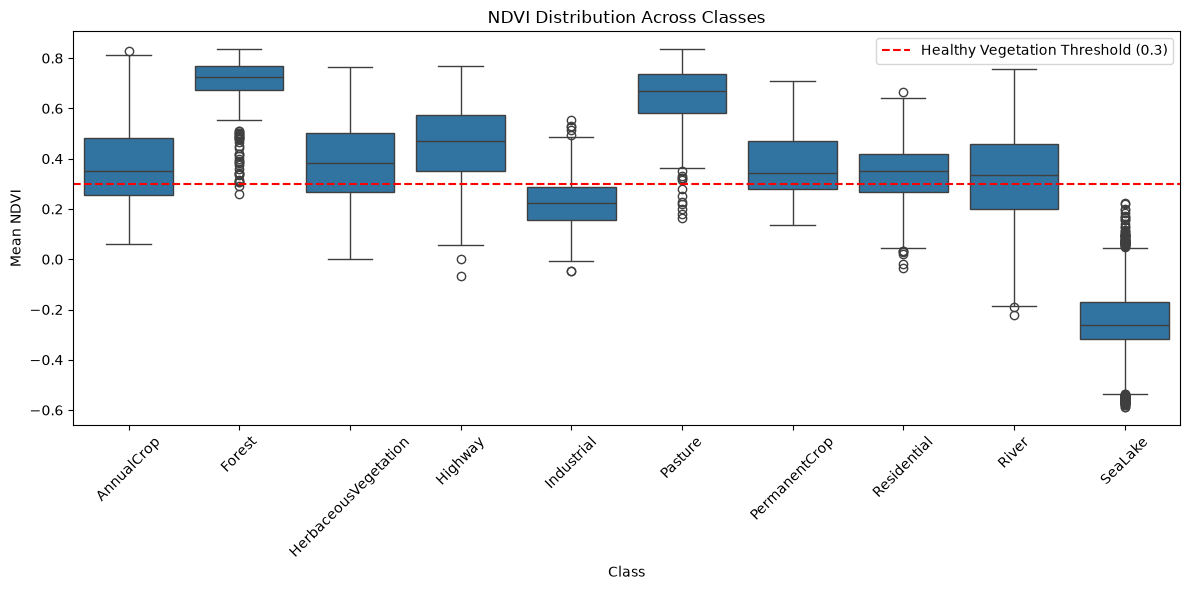

In [17]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=feature_df,
    x="classname",
    y="NDVI"
)

plt.axhline(
    y=0.3,
    color="red",
    linestyle="--",
    label="Healthy Vegetation Threshold (0.3)"
)

plt.xticks(rotation=45)
plt.title("NDVI Distribution Across Classes")
plt.xlabel("Class")
plt.ylabel("Mean NDVI")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/figures/ndvi_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### NDVI Analysis

- Forest and vegetation-related classes show higher NDVI values.
- Residential and Industrial classes generally have lower NDVI.
- The red dashed line at **0.3** represents the commonly used threshold for healthy vegetation.
- Most vegetation classes lie above this threshold, indicating dense green cover.

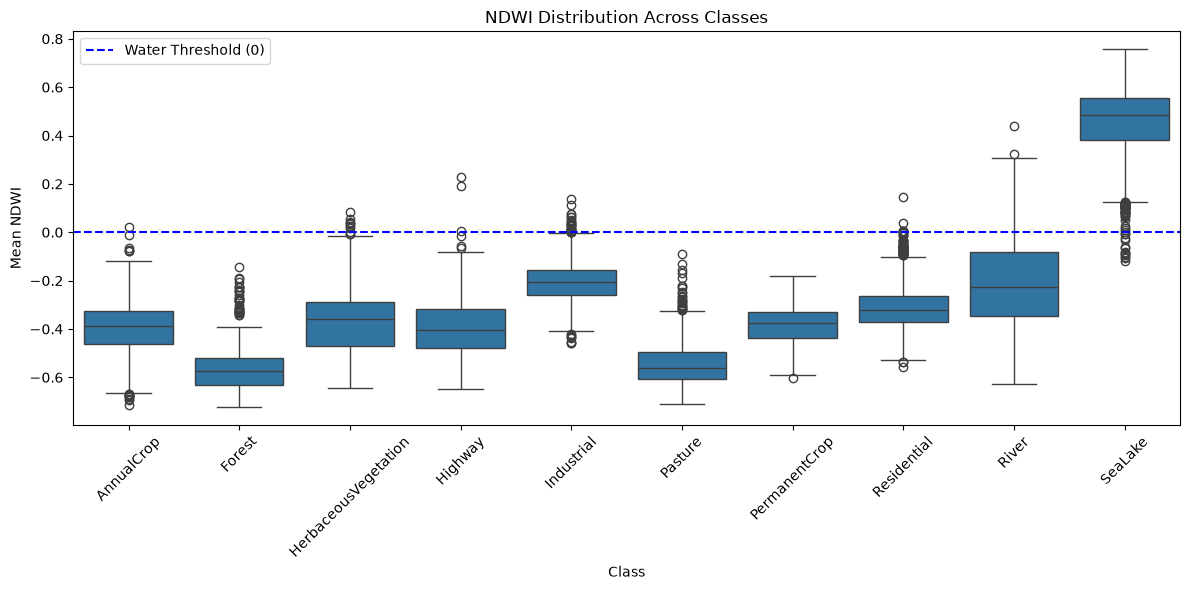

In [18]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=feature_df,
    x="classname",
    y="NDWI"
)

plt.axhline(
    y=0,
    color="blue",
    linestyle="--",
    label="Water Threshold (0)"
)

plt.xticks(rotation=45)
plt.title("NDWI Distribution Across Classes")
plt.xlabel("Class")
plt.ylabel("Mean NDWI")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/figures/ndwi_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### NDWI Analysis

- River and SeaLake classes tend to have higher NDWI values.
- Vegetation and urban classes mostly show lower NDWI values.
- The threshold at **0** helps distinguish water-rich regions from non-water areas.

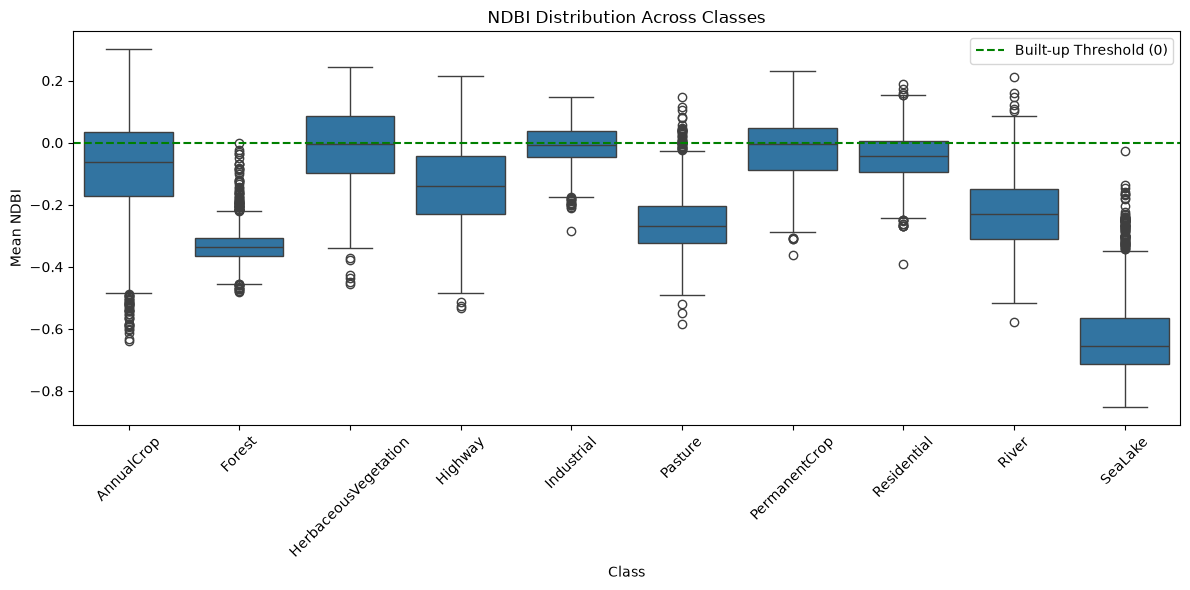

In [19]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=feature_df,
    x="classname",
    y="NDBI"
)

plt.axhline(
    y=0,
    color="green",
    linestyle="--",
    label="Built-up Threshold (0)"
)

plt.xticks(rotation=45)
plt.title("NDBI Distribution Across Classes")
plt.xlabel("Class")
plt.ylabel("Mean NDBI")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/figures/ndbi_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### NDBI Analysis

- Residential and Industrial classes generally have higher NDBI values.
- Forest and crop-related classes show lower NDBI values.
- Positive NDBI values usually indicate built-up surfaces, while negative values correspond to vegetation or water.

In [24]:
feature_columns = [
    "NDVI",
    "NDWI",
    "NDBI",
    "B1","B2","B3","B4","B5","B6","B7",
    "B8","B9","B10","B11","B12","B13"
]

X = feature_df[feature_columns].values
y = feature_df["classname"].values

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (18900, 16)


In [25]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X)

print("t-SNE completed!")


t-SNE completed!


In [26]:
tsne_df = pd.DataFrame({
    "TSNE-1": X_tsne[:,0],
    "TSNE-2": X_tsne[:,1],
    "Class": y
})

tsne_df.head()

,TSNE-1,TSNE-2,Class
0,29.170048,-46.436481,AnnualCrop
1,77.154594,54.692883,AnnualCrop
2,25.190893,65.709541,AnnualCrop
3,91.599663,5.869796,AnnualCrop
4,24.379478,65.573425,AnnualCrop


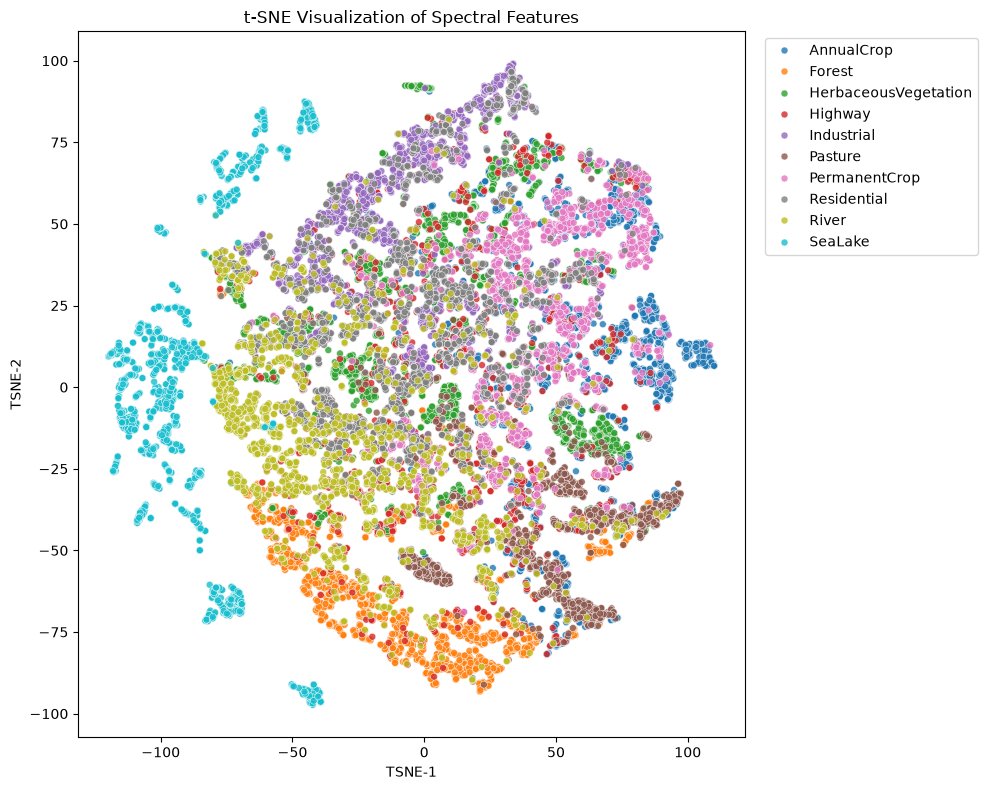

In [27]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=tsne_df,
    x="TSNE-1",
    y="TSNE-2",
    hue="Class",
    palette="tab10",
    s=25,
    alpha=0.8
)

plt.title("t-SNE Visualization of Spectral Features")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/tsne_spectral.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### t-SNE Visualization

- Each point represents one multispectral image.
- Images with similar spectral characteristics tend to form clusters.
- Vegetation, water bodies, and urban regions are expected to occupy different regions of the feature space.
- The clustering indicates that the spectral bands and derived indices provide meaningful information for separating land-cover classes.

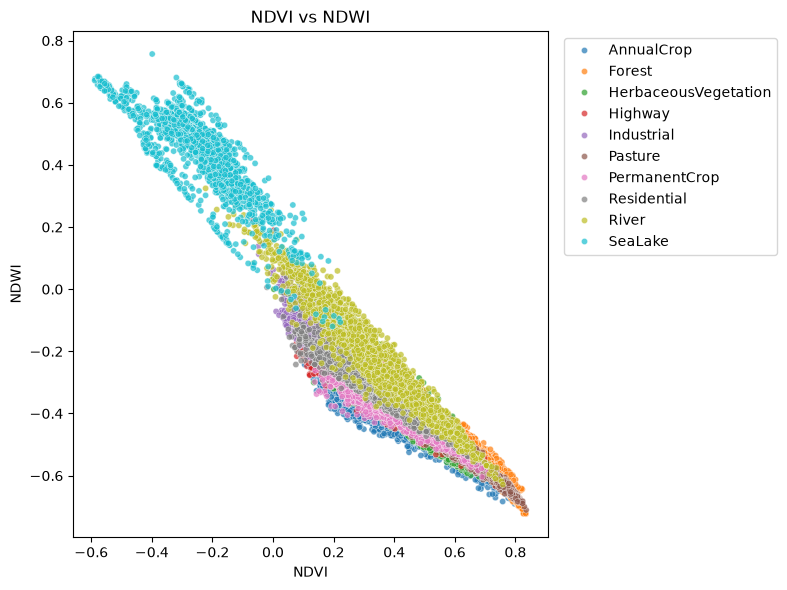

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=feature_df,
    x="NDVI",
    y="NDWI",
    hue="classname",
    palette="tab10",
    alpha=0.7,
    s=20
)

plt.title("NDVI vs NDWI")
plt.xlabel("NDVI")
plt.ylabel("NDWI")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

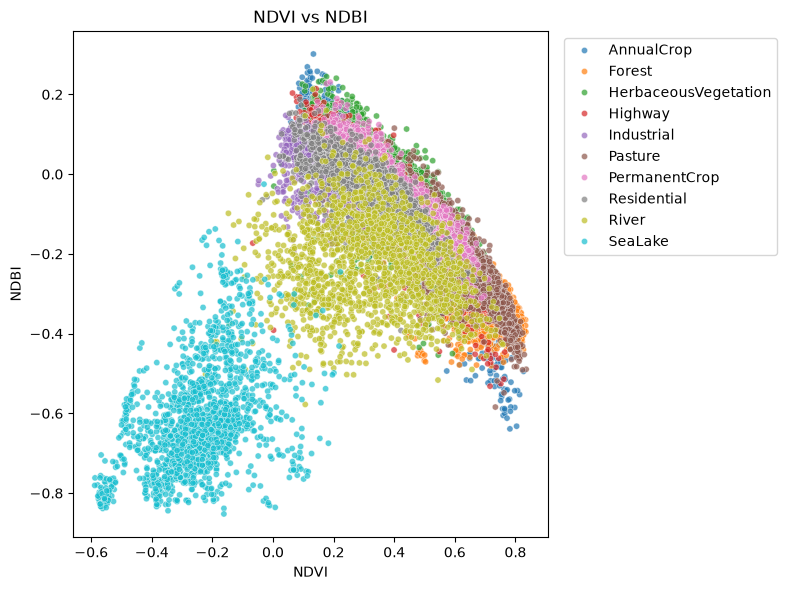

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=feature_df,
    x="NDVI",
    y="NDBI",
    hue="classname",
    palette="tab10",
    alpha=0.7,
    s=20
)

plt.title("NDVI vs NDBI")
plt.xlabel("NDVI")
plt.ylabel("NDBI")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

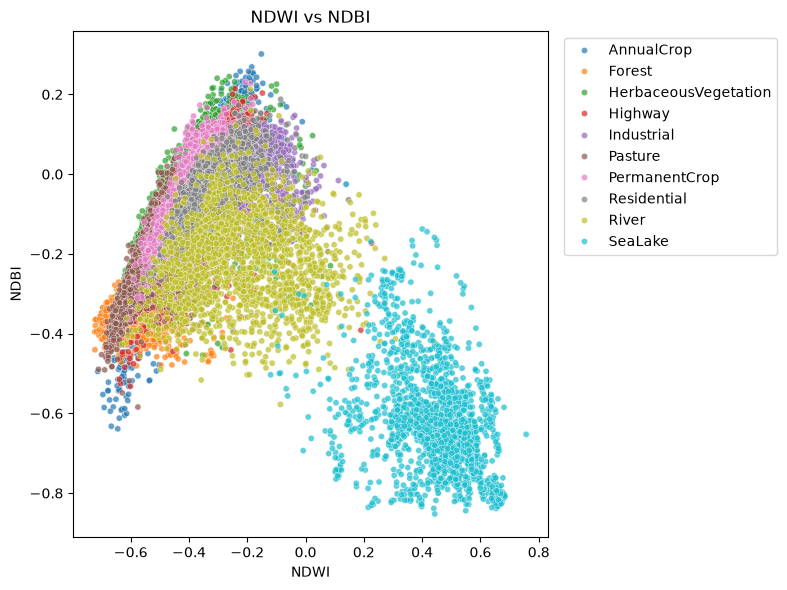

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=feature_df,
    x="NDWI",
    y="NDBI",
    hue="classname",
    palette="tab10",
    alpha=0.7,
    s=20
)

plt.title("NDWI vs NDBI")
plt.xlabel("NDWI")
plt.ylabel("NDBI")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

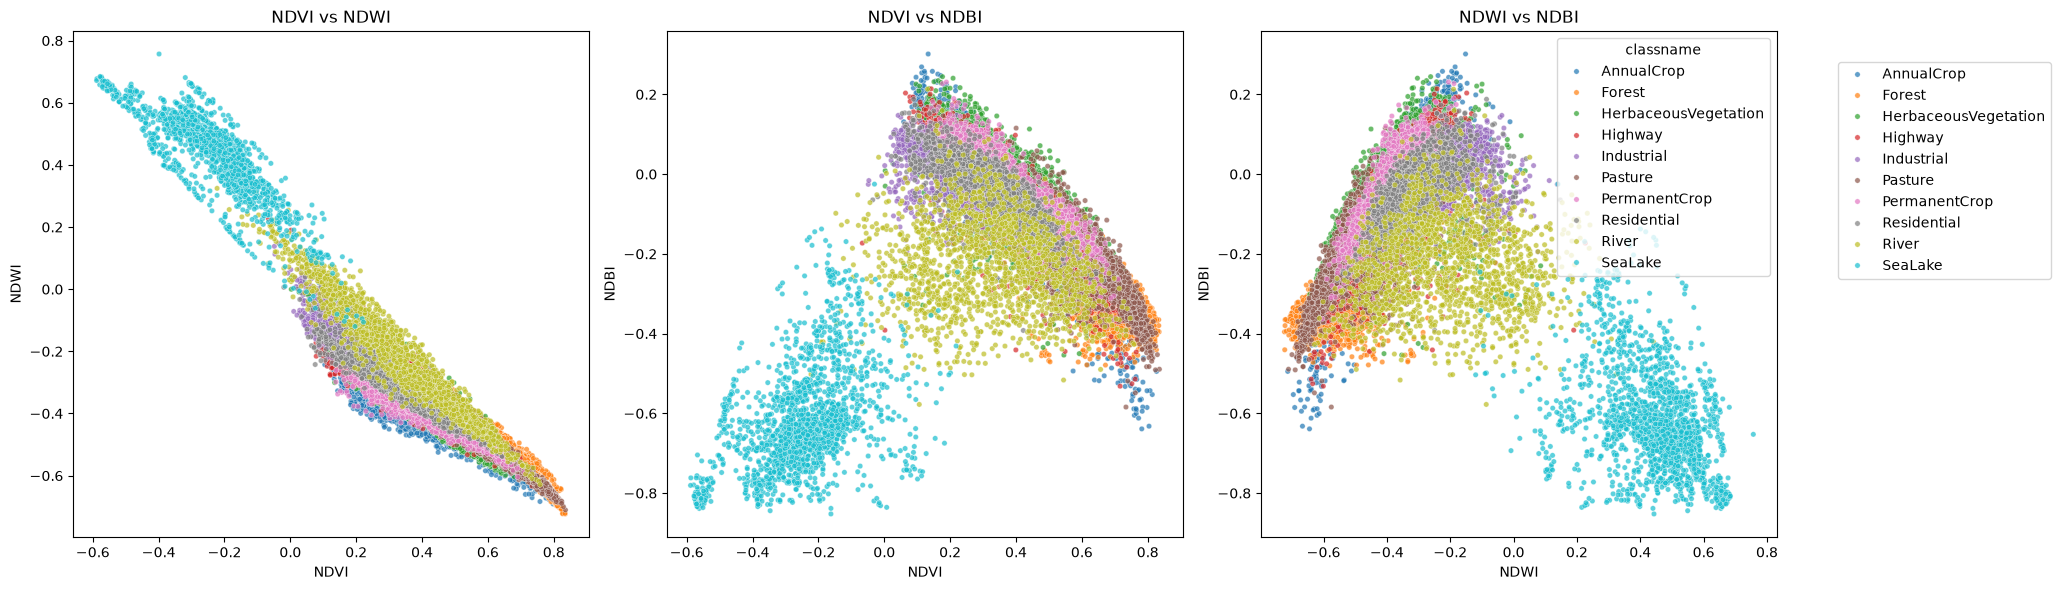

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

sns.scatterplot(
    data=feature_df,
    x="NDVI",
    y="NDWI",
    hue="classname",
    palette="tab10",
    alpha=0.7,
    s=15,
    ax=axes[0],
    legend=False
)
axes[0].set_title("NDVI vs NDWI")

sns.scatterplot(
    data=feature_df,
    x="NDVI",
    y="NDBI",
    hue="classname",
    palette="tab10",
    alpha=0.7,
    s=15,
    ax=axes[1],
    legend=False
)
axes[1].set_title("NDVI vs NDBI")

sns.scatterplot(
    data=feature_df,
    x="NDWI",
    y="NDBI",
    hue="classname",
    palette="tab10",
    alpha=0.7,
    s=15,
    ax=axes[2]
)
axes[2].set_title("NDWI vs NDBI")

handles, labels = axes[2].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.02,0.9),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/index_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Environmental Dashboard

- NDVI and NDWI help distinguish vegetation from water bodies.
- NDVI and NDBI show an inverse relationship for most vegetation and urban classes.
- Water classes generally have higher NDWI and lower NDBI values.
- Residential and Industrial regions tend to have higher NDBI values, indicating built-up surfaces.

In [32]:
feature_df["Environmental_Score"] = (
    feature_df["NDVI"] +
    feature_df["NDWI"] -
    feature_df["NDBI"]
)

feature_df.head()

,NDVI,NDWI,NDBI,B1,B2,B3,B4,B5,B6,B7,B8,B9,B10,B11,B12,B13,classname,label,Agri_Suitability,Environmental_Score
0,0.622316,-0.508975,-0.266997,1253.154785,1002.690674,961.897949,686.074707,1004.693604,2488.586426,3202.731445,2976.853760,564.735107,10.249512,1712.645264,800.822266,3471.855469,AnnualCrop,0,0.889313,0.380338
1,0.229259,-0.293470,0.092570,1672.066406,1601.828369,1664.692871,1932.335205,2152.745361,2832.455322,3228.053223,3088.992676,726.006104,15.598145,3724.273682,2833.703369,3550.711182,AnnualCrop,0,0.136689,-0.156782
2,0.190711,-0.272308,0.101259,1429.684814,1275.101318,1312.430908,1569.234375,1743.582031,2116.386963,2365.624756,2332.753418,782.765869,12.377930,2853.605225,2085.723145,2594.812012,AnnualCrop,0,0.089452,-0.182856
3,0.382773,-0.460044,-0.158925,1366.667725,1242.337402,1314.340820,1581.845947,1982.329102,3097.277100,3730.083008,3680.226074,1072.926025,12.764160,2606.924805,1440.965820,4306.681641,AnnualCrop,0,0.541698,0.081655
4,0.162643,-0.245796,0.113843,1432.065186,1288.161133,1341.239502,1605.499756,1764.315918,2060.484131,2285.408936,2219.954834,724.769043,13.104004,2785.394775,2167.130615,2472.804932,AnnualCrop,0,0.048800,-0.196996


In [33]:
score_df = (
    feature_df
    .groupby("classname")["Environmental_Score"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

score_df

,classname,Environmental_Score
0,SeaLake,0.833271
1,Forest,0.476740
2,Pasture,0.363944
3,River,0.344951
4,Highway,0.184810
5,Residential,0.074462
6,AnnualCrop,0.059615
7,HerbaceousVegetation,0.027783
8,Industrial,0.026262
9,PermanentCrop,0.010406


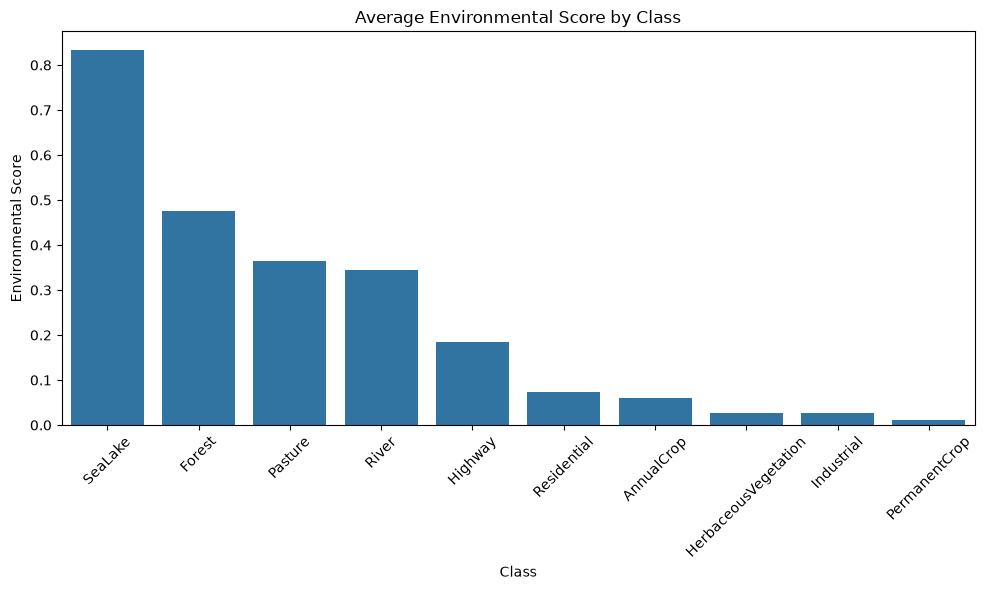

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=score_df,
    x="classname",
    y="Environmental_Score"
)

plt.xticks(rotation=45)

plt.title("Average Environmental Score by Class")
plt.xlabel("Class")
plt.ylabel("Environmental Score")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/environmental_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Environmental Suitability Score

A simple environmental score was computed using:

**Environmental Score = NDVI + NDWI − NDBI**

This score is intended only for exploratory analysis.

- Higher NDVI contributes positively because it indicates healthier vegetation.
- Higher NDWI contributes positively because it represents greater moisture or water presence.
- Higher NDBI reduces the score because it is associated with built-up areas.

The ranking provides a simple comparison of environmental characteristics across different land-cover classes.

# Environmental Insights Summary

- Forest and vegetation-related classes generally show the highest NDVI values, indicating healthier vegetation.
- River and SeaLake classes have comparatively higher NDWI values, reflecting the presence of water and higher moisture.
- Residential and Industrial classes tend to have higher NDBI values, which is consistent with built-up land-cover.
- The t-SNE visualization demonstrates that spectral features and derived indices help separate different land-cover classes into distinct clusters.
- The environmental dashboard highlights the relationships between vegetation, moisture, and urbanization, providing useful insights into the characteristics of each class.